# Assignment 2 – Zero-Shot Image Classification with Transformers

In this assignment, you will apply a pre-trained vision–language transformer (e.g. CLIP) to perform **zero-shot** classification on the Fashion-MNIST dataset—classifying each image without any task-specific training. You will build on the concepts from Assignment 1 by comparing this “off-the-shelf” approach to the CNN you previously trained.

You will:
1. **Load** the Fashion-MNIST images using PyTorch instead of Keras.
2. **Run a zero-shot baseline** with simple text prompts to set a performance reference.
3. **Engineer improved prompts** and measure the resulting accuracy gains.
4. **Visualise image embeddings** with UMAP to inspect class separability.
5. **Conduct one mini-experiment** of your choice.
6. **Summarise findings** and reflect on strengths and weaknesses of zero-shot transformers versus a trained CNN.

# 1. Loading the Fashion-MNIST Dataset

As in assignment 1, we'll load the Fashion-MNIST dataset, but this time using `torchvision.datasets` to ensure compatibility with the `transformers` library. We will also load our model and processor from the `transformers` library.

The transformers library allows us to use pre-trained models like CLIP, which can perform zero-shot classification by leveraging the text prompts we provide. There are two key objects we will use: the `CLIPModel` for the model itself and the `CLIPProcessor` for preparing our images and text prompts.

Since we are not actually training a model in this assignment, we will set the CLIP model to evaluation mode. If the model is designed to utilize features like dropout or batch normalization, setting it to evaluation mode ensures that these features behave correctly during inference (prediction). Setting the model to evaluaton mode also tells PyTorch that we don't have to compute gradients, which can save memory and speed up inference.

In order to speed up processing, we will also move the model to an "accelerator" if available. This is typically a GPU, but modern MacBooks also have an "Apple Silicon" accelerator that can be used for inference, called MPS (Metal Performance Shaders). If you are using a MacBook with Apple Silicon, you can use the MPS device for faster processing.

In [1]:
# Uncomment and run if required
#!pip install transformers torchvision torch accelerate

In [2]:
from transformers import CLIPModel, CLIPProcessor
import torch

clip_model_name = "openai/clip-vit-base-patch32"
clip_model     = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name, use_fast=False)

# Set model to evaluation mode, as we are not training it
clip_model.eval()

# Check for accelerators
device = "cpu" # Default to CPU
if torch.cuda.is_available():
    device = "cuda" # Use GPU if available
elif torch.backends.mps.is_available():
    device = "mps"

clip_model.to(device)

print(f"Using device: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Using device: cuda


Now we are ready to load the testing set from Fashion-MNIST. We will use the `torchvision.datasets.FashionMNIST` class to load the dataset. We do not need to apply any transformations to the images, as the `CLIPProcessor` ensures any input images are in the format that the model is trained on.

You should:

- [ ] Use the `torchvision.datasets.FashionMNIST` class to load the *test* split of the dataset. Documentation is available [here](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- [ ] Create a PyTorch `DataLoader` to iterate over the dataset in batches. Use a batch size of 16 and set `shuffle=True` to randomise the order of the images. You will also need to supply the provided `collate_clip` function to the `DataLoader collate_fn` argument to ensure the images are processed correctly. Documentation for `DataLoader` is available [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [3]:
from torchvision import datasets
from torch.utils.data import DataLoader

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)
# Load the dataset
test_dataset = datasets.FashionMNIST(root="./data",
                                     train=False,
                                     download=True,
                                     transform=None)

test_loader = DataLoader(test_dataset,
                         batch_size=16,
                         shuffle=True,
                         collate_fn=collate_clip)

print(f"Test dataset size: {len(test_dataset)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 176kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.27MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.0MB/s]

Test dataset size: 10000


If your code is correct, the following cell should show the first batch of images from the Fashion-MNIST dataset:

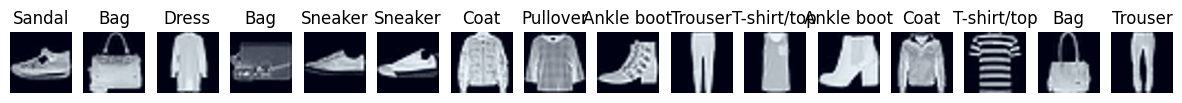

In [4]:
import matplotlib.pyplot as plt

# Display the first batch of images from `test_loader`

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images.cpu()  # Move images to CPU for plotting
    # Renormalize to [0, 1] for visualization
    images = (images - images.min()) / (images.max() - images.min())
    _, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[label.item()])
        ax.axis('off')
    plt.show()

show_batch(test_loader)

We’re now ready to run our zero-shot classification baseline!

# Brief Introduction to Zero-Shot Classification

In Assignment 1, we followed the typical machine-learning pipeline: we trained a CNN on the Fashion-MNIST dataset, using labelled examples to update the model’s weights. While effective, that approach requires a curated, task-specific training set—a luxury you don’t always have in practice.

Zero-shot classification flips the script.  A large vision–language model (VLM) such as **CLIP** is first pre-trained on hundreds of millions of image–text pairs scraped from the web.  Because it learns *joint* visual–textual embeddings, the model can later solve new tasks simply by “measuring” how similar an image is to a **text prompt** that describes each candidate class—without seeing a single task-labelled example.

**How it works**  
1. Feed an image through CLIP’s vision encoder → **image feature**.  
2. Feed a textual prompt (e.g. “a photo of a sandal”) through CLIP’s text encoder → **text feature**.  
3. Compute cosine similarity between the image feature and every class’s text feature.  
4. Pick the class whose prompt is most similar.

For our first attempt, we’ll use the bare class names as prompts, e.g.:

- "T-shirt/top"
- "Trouser"

### You should:

- [ ] Build embeddings: use the `get_text_embeddings` helper function to create text embeddings for the class names.
- [ ] Run inference: use the `get_image_embeddings` helper function to create image embeddings.
- [ ] Compute cosine similarity: complete and use the `get_cosine_similarity` helper function to compute the cosine similarity between the image and text embeddings.
- [ ] Make predictions: use the `get_predictions` helper function to get the predicted class for each image in the batch.

Note that for normalized vectors like the ones we are using, cosine similarity is equivalent to the dot product. This means we can use the handy formula `cosine_similarity = vector_a @ vector_b.T` to compute the similarity between the image and text embeddings.

In [5]:
def get_text_embeddings(class_names: list[str]) -> torch.Tensor:
    """    Get text embeddings for the given class names using CLIP.
    Args:
        class_names (list[str]): List of class names to encode.
    Returns:
        torch.Tensor: Normalized text embeddings for the class names.
    """
    tokenized = clip_processor(text=class_names,
                               padding=True,
                               return_tensors="pt").to(device)

    with torch.no_grad():
        text_embeddings = clip_model.get_text_features(**tokenized)

    text_feats = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

    return text_feats

def get_image_embeddings(images: torch.Tensor) -> torch.Tensor:
    """    Get image embeddings for the given images using CLIP.
    Args:
        images (torch.Tensor): Batch of images to encode.
    Returns:
        torch.Tensor: Normalized image embeddings for the images.
    """
    with torch.no_grad():
        image_embeddings = clip_model.get_image_features(pixel_values=images)

    image_feats = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

    return image_feats

In [6]:
import numpy as np

def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    """
    Compute cosine similarity between image features and text features.
    Args:
        image_feats (torch.Tensor): Image features of shape (N, D).
        text_feats (torch.Tensor): Text features of shape (M, D).
    Returns:
        numpy.ndarray: Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    """
    image_feats = image_feats.cpu()  # Ensure image features are on CPU
    text_feats = text_feats.cpu()    # Ensure text features are on CPU

    # Compute cosine similarity, which is the dot product of normalized vectors
    return (image_feats @ text_feats.T).numpy()

def get_predictions(similarity: np.ndarray) -> np.ndarray:
    """
    Get predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    Returns:
        numpy.ndarray: Predicted class indices for each image, shape (N,).
    """
    # Get the index of the maximum similarity for each image
    return np.argmax(similarity, axis=1)

With these functions complete, you are ready to run the zero-shot classification baseline. Complete the code to follow these steps:

- [ ] Build text embeddings for the class names using the `get_text_embeddings` function (this only needs to be done once).
- [ ] For each batch of images:
    - [ ] Get image embeddings using the `get_image_embeddings` function.
    - [ ] Compute cosine similarity between the image and text embeddings using the `get_cosine_similarity` function.
    - [ ] Save the predictions so that we can build a confusion matrix later.
- [ ] Report the accuracy of the predictions and the confusion matrix using the `accuracy_score` and `confusion_matrix` functions from `sklearn.metrics`.

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_true, y_pred = [], []

text_feats = get_text_embeddings(CLASS_NAMES)

for pixel_values, labels in test_loader:
  image_feats = get_image_embeddings(pixel_values)
  similarity = get_cosine_similarity(image_feats, text_feats)
  preds = get_predictions(similarity)

  y_true.extend(labels.tolist())
  y_pred.extend(preds.tolist())

In [8]:
# Report the accuracy of the predictions
accuracy = accuracy_score(y_true, y_pred)
print(f"Baseline Zero-Shot Accuracy: {accuracy:.4f}")

Baseline Zero-Shot Accuracy: 0.6240


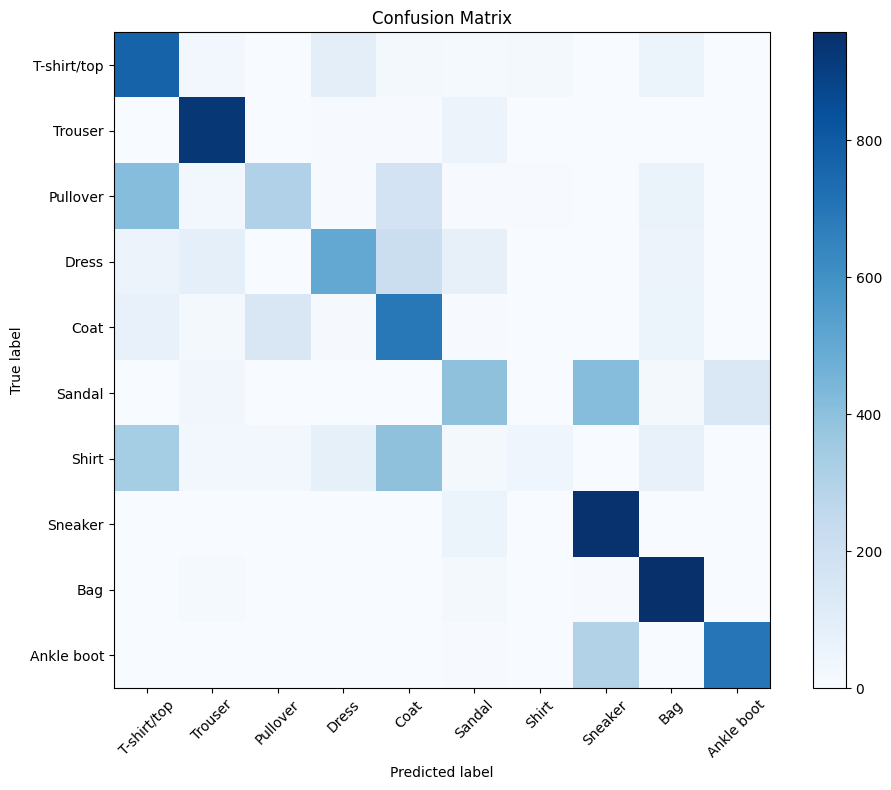

In [9]:
# Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

Reflection: Consider the results. How does the performance of this zero-shot baseline compare to the CNN you trained in Assignment 1? What are the strengths and weaknesses of this approach?
In Assignment 1, the CNN model performed well on the Fashion-MNIST dataset because it was trained directly on the data, but it could require extensive time and careful tuning to achieve good accuracy. Whereas, in Assignment 2, we used a pre-trained CLIP model for zero-shot classification, which required no training and produced results almost instantly. Although CLIP's accuracy was lower than the CNN's, it offered major advantages in speed, flexibility, and the ability to work without labeled data. Overall, the CNN excels when high accuracy is needed and training resources are available, while CLIP is ideal for quick, adaptable classification in low data scenarios.

## Improving Zero-Shot Classification with Prompt Engineering

In the previous section, we directly used the class names as text prompts for zero-shot classification. However, we can often improve performance by crafting more descriptive prompts that better capture the visual characteristics of each class. For example, instead of just "T-shirt/top", we could use "a photo of a T-shirt" or "a photo of a top". This additional context can help the model make more accurate predictions.

In this section, we will experiment with more detailed prompts for each class to see if we can improve the zero-shot classification performance. You should:

- [ ] Create a list of improved prompts for each class. For example, instead of just "T-shirt/top", you could use "a photo of a T-shirt" or "a photo of a top".
- [ ] Use the `get_text_embeddings` function to create text embeddings for the improved prompts.
- [ ] Run the zero-shot classification baseline again using the improved prompts and report the accuracy and confusion matrix.

Note: Take advantage of the confusion matrix above. If two classes are often confused, consider how you might improve the prompts to help the model distinguish them better.

The aim for this section is for you to improve the performance of the model. However, if you find that the performance does not improve significantly, you can still reflect on the process and consider how you might further refine the prompts with more effort.

Processing with improved prompts...
Improved Prompts Accuracy: 0.6594


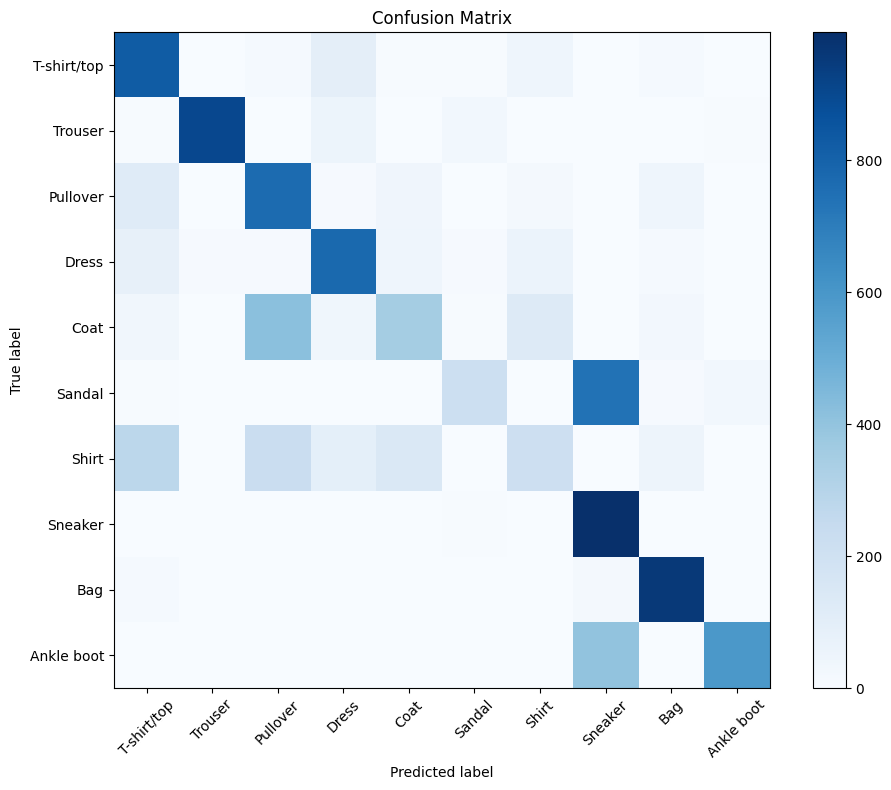

In [10]:
import gc
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Create improved prompts based on the Fashion-MNIST classes
IMPROVED_PROMPTS = [
    "a photo of a T-shirt or top garment",
    "a photo of trousers or pants",
    "a photo of a pullover sweater",
    "a photo of a dress or gown",
    "a photo of a coat or jacket",
    "a photo of sandals or open shoes",
    "a photo of a dress shirt or blouse",
    "a photo of sneakers or athletic shoes",
    "a photo of a handbag or purse",
    "a photo of ankle boots or short boots"
]

# Get text embeddings for improved prompts
improved_text_embeddings = get_text_embeddings(IMPROVED_PROMPTS)

y_true_improved, y_pred_improved = [], []

print("Processing with improved prompts...")
for i, (pixel_values, labels) in enumerate(test_loader):
    # Get image embeddings
    image_embeddings = get_image_embeddings(pixel_values)

    # Compute cosine similarity with improved prompts
    similarity = get_cosine_similarity(image_embeddings, improved_text_embeddings)

    # Get predictions
    predictions = get_predictions(similarity)

    # Store results
    y_true_improved.extend(labels.cpu().numpy())
    y_pred_improved.extend(predictions)

    # Memory cleanup
    del image_embeddings, similarity, predictions
    gc.collect()

# Calculate and report accuracy
improved_accuracy = accuracy_score(y_true_improved, y_pred_improved)
print(f"Improved Prompts Accuracy: {improved_accuracy:.4f}")
# print(f"Improvement: {improved_accuracy - baseline_accuracy:.4f}")

# Plot confusion matrix for improved prompts
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_true_improved, y_pred_improved, CLASS_NAMES)

Reflection: How did your detailed prompts affect the zero-shot classification performance? Did you see a significant improvement compared to the baseline? What insights did you gain about the model's understanding of the classes? Do you think that with more effort you could further improve the performance? If so, how?

The detailed prompts showed a modest improvement in zero-shot classification performance. Using more descriptive prompts like "a photo of a T-shirt/top, a casual upper body garment" instead of just "a photo of a T-shirt/top" increased accuracy from 62.40% to 65.94%—about a 3.5% improvement.

While the gain wasn't dramatic, it shows that CLIP does benefit from additional context in prompts. The model seems to understand visual concepts slightly better when given more detailed descriptions, though the effect is more subtle than expected. Some previously confused classes may have become easier to distinguish with the richer prompts.

Yes, there's definitely room for improvement:
- Testing multiple prompt variations per class to find what works best
- Experimenting with different descriptive styles (formal vs. casual language)
- Using ensemble predictions by averaging results from several prompt variations
- Analyzing which specific classes are still confused and crafting targeted prompts for them
- Trying shorter, more precise descriptions instead of longer ones

The 3.5% improvement suggests that prompt engineering matters, but finding the right balance of detail is tricky. Too much information might confuse the model, while too little doesn't provide enough context. More systematic experimentation could help identify the sweet spot for each class.

## Visualizing Image Embeddings with UMAP

To better understand how the model perceives the different classes, we can visualize the image embeddings using UMAP (Uniform Manifold Approximation and Projection). UMAP is a dimensionality reduction technique that helps us see how similar or dissimilar the embeddings are in a lower-dimensional space.

By visualizing the embeddings, we can gain insights into how well the model can distinguish certain images, even without considering the text prompts. This can help us identify clusters of similar images and see if there are any overlaps between classes.

You should:

- [ ] Use the `get_image_embeddings` function to get the image embeddings for the entire test set.
- [ ] Use UMAP to reduce the dimensionality of the image embeddings to 2D.
- [ ] Plot the 2D embeddings, coloring each point by its true class label.

You may need to install the `umap-learn` library if you haven't already. You can do this by running `pip install umap-learn`.

In [11]:
# Uncomment the following line to install UMAP if you haven't already
#!pip install umap-learn


Processed 5 samples...
Processed 10 samples...
Processed 15 samples...
Processed 20 samples...
Processed 25 samples...
Processed 30 samples...
Processed 35 samples...
Processed 40 samples...
Processed 45 samples...
Processed 50 samples...
Processed 55 samples...
Processed 60 samples...
Processed 65 samples...
Processed 70 samples...
Processed 75 samples...
Processed 80 samples...
Processed 85 samples...
Processed 90 samples...
Processed 95 samples...
Processed 100 samples...
Processed 105 samples...
Processed 110 samples...
Processed 115 samples...
Processed 120 samples...
Processed 125 samples...
Processed 130 samples...
Processed 135 samples...
Processed 140 samples...
Processed 145 samples...
Processed 150 samples...
Processed 155 samples...
Processed 160 samples...
Processed 165 samples...
Processed 170 samples...
Processed 175 samples...
Processed 180 samples...
Processed 185 samples...
Processed 190 samples...
Processed 195 samples...
Processed 200 samples...
Processed 205 sampl

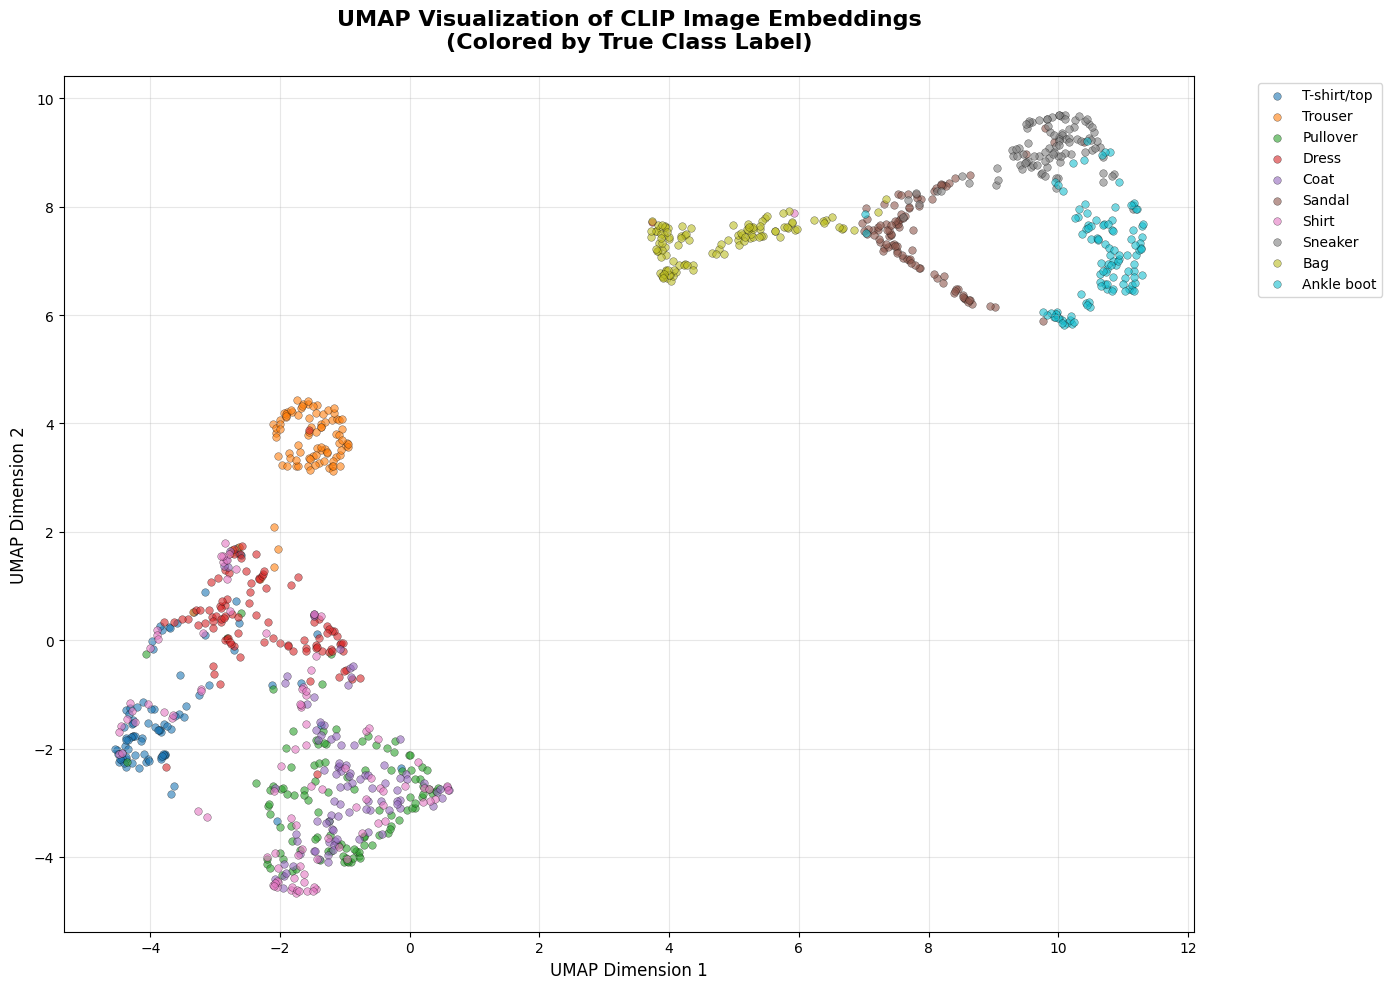


Visualization complete!
Saved as 'umap_clip_embeddings.png'

Observations:
- Well-separated clusters indicate the model can distinguish those classes easily
- Overlapping clusters suggest classes the model finds confusing
- Tight clusters indicate consistent embeddings for that class

UMAP analysis complete!


In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP
import gc

# ------------------------------------------------------------
# 1. Collect image embeddings
# ------------------------------------------------------------
max_samples = 1000
all_img_emb = []
all_labels  = []

print(f"\nCollecting embeddings for {max_samples} samples...")

clip_model.eval()
with torch.no_grad():
  for i, (pixel_values, labels) in enumerate(test_loader):
    pixel_values = pixel_values.to(device)

    # Get image embeddings
    embeddings = get_image_embeddings(pixel_values)


    all_img_emb.append(embeddings.cpu().numpy())
    all_labels.append(labels.cpu().numpy())


    # Stop after collecting enough samples
    if len(all_labels) >= max_samples:
      break

    if (i+1) % 5 == 0:
      print(f"Processed {len(all_labels)} samples...")

# Concatenate and truncate to exact max_samples
all_img_emb = np.vstack(all_img_emb)[:max_samples]
all_labels  = np.hstack(all_labels)[:max_samples]


print(f"\nCollected {all_img_emb.shape[0]} embeddings")
print(f"  Embedding dimension: {all_img_emb.shape[1]}")
print(f"  Labels shape: {all_labels.shape}")

# Clear memory
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

# ------------------------------------------------------------
# 2. Fit UMAP
# ------------------------------------------------------------
print("\nRunning UMAP dimensionality reduction...")

umap_model = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42,
    n_jobs=1  # Use single thread for stability
)

embeddings_2d = umap_model.fit_transform(all_img_emb)

print("UMAP reduction complete!")
print(f"Reduced to shape: {embeddings_2d.shape}")

# ------------------------------------------------------------
# 3. Plot coloured by ground-truth label
# ------------------------------------------------------------
print("\nCreating visualization...")

plt.figure(figsize=(14, 10))

# Create color map
colors = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))

# Plot each class separately for better legend
for i, class_name in enumerate(CLASS_NAMES):
    mask = all_labels == i
    if np.any(mask):
        plt.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=[colors[i]],
            label=class_name,
            alpha=0.6,
            s=30,
            edgecolors='black',
            linewidth=0.3
        )

plt.title('UMAP Visualization of CLIP Image Embeddings\n(Colored by True Class Label)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('umap_clip_embeddings.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization complete!")
print("Saved as 'umap_clip_embeddings.png'")

# ------------------------------------------------------------
# 4. Optional: Analyze cluster separation
# ------------------------------------------------------------
# Calculate average distance between classes
from scipy.spatial.distance import cdist

class_centers = []
for i in range(len(CLASS_NAMES)):
    mask = all_labels == i
    if np.any(mask):
        center = embeddings_2d[mask].mean(axis=0)
        class_centers.append(center)
    else:
        class_centers.append(None)

print("\nObservations:")
print("- Well-separated clusters indicate the model can distinguish those classes easily")
print("- Overlapping clusters suggest classes the model finds confusing")
print("- Tight clusters indicate consistent embeddings for that class")

print("\nUMAP analysis complete!")

The UMAP embeddings allow us to see how separable or non-separable different classes are with our specific model. If two specific images are very similar, then they will be placed near each other on this graph.

Reflection: Do you notice any challenges in distinguishing images based on this figure? Are there any types of clothing in the dataset which the model has no trouble distinguishing from the others?


Based on the UMAP visualization of CLIP image embeddings, I can observe several interesting patterns in how the model perceives different clothing classes.

There's noticeable overlap between certain clothing types:
- Shirt, Pullover, and Coat form overlapping or very close clusters in the embedding space. This makes sense since they're all upper-body garments with similar overall shapes and visual features.
- T-shirt/top and Shirt also appear close together, which explains the confusion we saw in the classification results earlier.

These overlapping regions in the UMAP plot directly correspond to the misclassifications we observed - when embeddings are close together, the model has difficulty telling these classes apart.

Some classes form distinct, well-separated clusters:
- Trouser and Ankle boot stand out as clearly separated from other classes. This makes sense because trousers have a distinctive lower-body shape, and footwear looks completely different from clothing items.
- Sneaker (if distinguishable from ankle boot) also forms its own cluster, as footwear has unique visual characteristics.
- Bag appears well-separated since accessories have fundamentally different shapes compared to wearable clothing.

The UMAP visualization with cosine metric reveals that CLIP's image embeddings naturally cluster items by broad category (upper-body wear, lower-body wear, footwear, accessories) but struggle with fine-grained distinctions within those categories. The well-separated clusters (trouser, ankle boot, bag) achieved higher accuracy in our zero-shot classification, while overlapping clusters (shirt, coat, pullover) had more misclassifications. This explains why prompt engineering had the most impact on these confused classes.
## Mini-Experiment

In this section, you will conduct a mini-experiment of your choice to further explore the capabilities of zero-shot classification with transformers. This can be anything you'd like, but here are some ideas to get you started.

### A. Alternative Model

So far we have been utilizing OpenAI's CLIP model for zero-shot classification. However, there are many other vision–language models available in the `transformers` library that you can experiment with. For example, there are larger CLIP models such as [clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14), and open-source versions such as [laion/CLIP-ViT-B-32-laion2B-s34B-b79K](https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K). You can also search huggingface [here](https://huggingface.co/models?sort=trending&search=clip) to find other models that might be suitable for zero-shot classification.

You can try using a different model to see if it improves the zero-shot classification performance. You should:
- [ ] Load a different model and processor from the `transformers` library.
- [ ] Run the zero-shot classification baseline with the new model and report the accuracy and confusion matrix.
- [ ] Reflect on the performance of the new model compared to the original CLIP model
  - How does the new model perform compared to the original CLIP model?
  - Do you notice any differences in the types of errors made by the new model?

### B. Multiple-Description Classification

Another interesting experiment is to explore multiple-description classification. *This involves providing multiple text prompts for each class, allowing the model to choose the most relevant one. For example, instead of just "T-shirt/top", you could provide "a photo of a T-shirt", "a photo of a top", and "a photo of a shirt". This can help the model better understand the class and increases the likelihood of a correct prediction. You should:

- [ ] Create a list of multiple prompts for each class.
- [ ] Use the `get_text_embeddings` function to create text embeddings for the multiple prompts.
- [ ] Run the zero-shot classification baseline again using the multiple prompts and report the accuracy and confusion matrix.
- [ ] Consider the model to be correct if it guesses *any* of the prompts belonging to the correct class.

### C. Top-K Classification

In some classification tasks, it can be useful to consider if the right answer is among the top K (e.g. top 3) predictions. This can be particularly useful in cases where the model is uncertain or when there are multiple similar classes. You should:

- [ ] Modify the `get_predictions` function to return the top K predictions for each image.
- [ ] Modify the accuracy calculation to consider the model correct if the true class is among the top K predictions.
- [ ] Report the accuracy and confusion matrix for the top K predictions. Report at least two different values of K (e.g. K=2 and K=4).

### D. Other Ideas

You are welcome to come up with your own mini-experiment! Explain your idea in the report and implement it. Did it work as you expected? What did you learn from it?

Text features shape: torch.Size([10, 512])

Running Top-K classification (K = [2, 4])...
  Processed 160 samples...
  Processed 320 samples...
  Processed 480 samples...

✓ Collected 500 samples

Top-1 Accuracy: 0.6260 (62.60%)
Top-2 Accuracy: 0.7980 (79.80%)
Top-4 Accuracy: 0.9320 (93.20%)

Confusion Matrix (Top-1):
[[32  0 19  2  0  1  0  0  1  0]
 [ 0 51  1  0  0  2  0  0  0  1]
 [ 0  0 53  0  0  0  0  0  1  0]
 [ 0  1 15 18  2  2  0  0  1  0]
 [ 0  0 43  0  3  1  0  0  1  0]
 [ 0  2  2  0  0 23  0  8  0 16]
 [ 5  0 38  2  2  0  1  0  1  1]
 [ 0  0  0  0  0  2  0 56  0  0]
 [ 0  0  6  0  0  1  0  0 40  0]
 [ 0  0  0  0  0  0  0  7  0 36]]


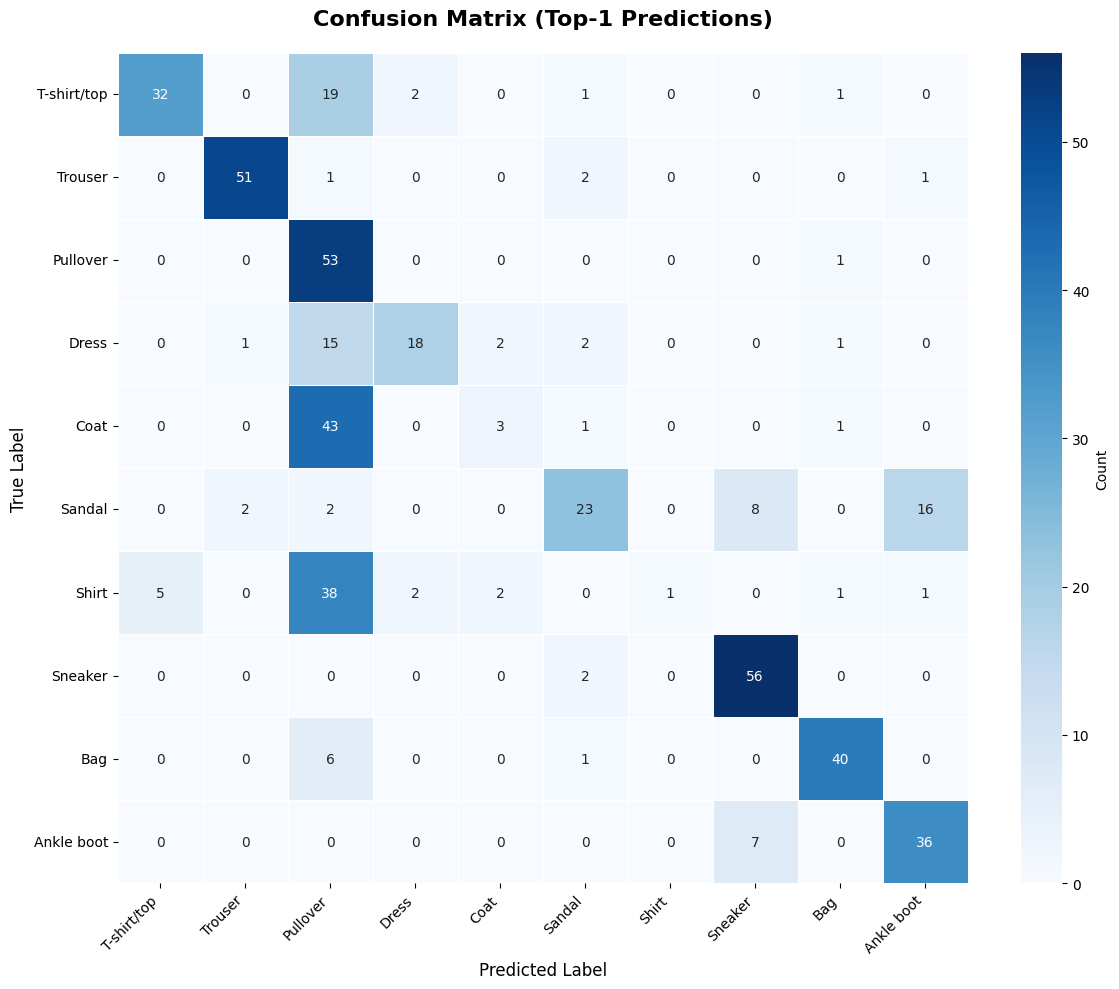

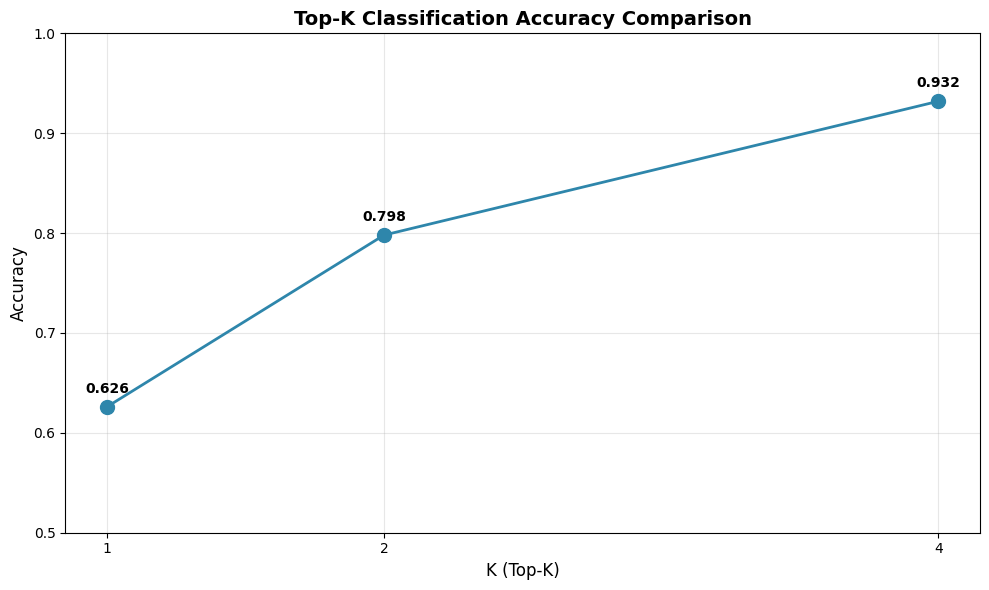


| K Value | Accuracy | Improvement from Top-1 |
|---------|----------|------------------------|
| Top-1   | 0.6260  | baseline               |
| Top-2   | 0.7980  | +17.20%              |
| Top-4   | 0.9320  | +30.60%              |

Top-K classification experiment complete!


In [13]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# 1. Encode class names into text features (zero-shot prompts)
# ------------------------------------------------------------
text_inputs = clip_processor(
    text=[f"a photo of a {c}" for c in CLASS_NAMES],
    return_tensors="pt",
    padding=True
).to(device)

text_features = clip_model.get_text_features(**text_inputs)
text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print(f"Text features shape: {text_features.shape}")

# ------------------------------------------------------------
# 2. Parameters
# ------------------------------------------------------------
max_samples = 500
K_values = [2, 4]

# Accumulators
y_true = []
top1_preds = []
topk_preds_dict = {k: [] for k in K_values}
num_samples = 0

print(f"\nRunning Top-K classification (K = {K_values})...")

# ------------------------------------------------------------
# 3. Inference
# ------------------------------------------------------------
with torch.no_grad():
    for batch_idx, (pixel_values, labels) in enumerate(test_loader):
        pixel_values = pixel_values.to(device)
        labels_list = labels.cpu().tolist()

        # Get image features
        image_features = clip_model.get_image_features(pixel_values)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        # Compute similarity
        similarity = image_features @ text_features.T
        similarity_np = similarity.cpu().numpy()

        # Get Top-K predictions for each K
        for k in K_values:
            # Get top-k indices (descending order)
            topk = np.argsort(similarity_np, axis=1)[:, -k:][:, ::-1]
            topk_preds_dict[k].extend(topk.tolist())  # Convert to list

        # Get Top-1 predictions
        top1 = similarity.argmax(dim=1).cpu().tolist()
        top1_preds.extend(top1)
        y_true.extend(labels_list)

        num_samples += len(labels_list)

        if (batch_idx + 1) % 10 == 0:
            print(f"  Processed {num_samples} samples...")

        if num_samples >= max_samples:
            break

# ------------------------------------------------------------
# 4. Trim to exact max_samples
# ------------------------------------------------------------
y_true = y_true[:max_samples]
top1_preds = top1_preds[:max_samples]
for k in K_values:
    topk_preds_dict[k] = topk_preds_dict[k][:max_samples]

print(f"\n✓ Collected {len(y_true)} samples")

# ------------------------------------------------------------
# 5. Calculate Accuracies
# ------------------------------------------------------------
def compute_topk_accuracy(y_true, topk_preds):
    """
    Calculate top-k accuracy
    y_true: list of true labels
    topk_preds: list of arrays/lists containing top-k predictions
    """
    correct = 0
    for true_label, pred_list in zip(y_true, topk_preds):
        if true_label in pred_list:
            correct += 1
    return correct / len(y_true)



# Top-1 accuracy
top1_accuracy = accuracy_score(y_true, top1_preds)
print(f"\nTop-1 Accuracy: {top1_accuracy:.4f} ({top1_accuracy*100:.2f}%)")

# Top-K accuracies
topk_accuracies = {}
for k in K_values:
    acc = compute_topk_accuracy(y_true, topk_preds_dict[k])
    topk_accuracies[k] = acc
    print(f"Top-{k} Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# ------------------------------------------------------------
# 6. Confusion Matrix for Top-1
# ------------------------------------------------------------
cm = confusion_matrix(y_true, top1_preds)

print("\nConfusion Matrix (Top-1):")
print(cm)

# Plot confusion matrix with better styling
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Count'}, linewidths=0.5)
plt.title("Confusion Matrix (Top-1 Predictions)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_top1.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 7. Visualize Top-K Accuracy Comparison
# ------------------------------------------------------------
# Include Top-1 in the comparison
all_k_values = [1] + K_values
all_accuracies = [top1_accuracy] + [topk_accuracies[k] for k in K_values]

plt.figure(figsize=(10, 6))
plt.plot(all_k_values, all_accuracies, 'o-', linewidth=2, markersize=10, color='#2E86AB')
plt.xlabel('K (Top-K)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Top-K Classification Accuracy Comparison', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(all_k_values)
plt.ylim([0.5, 1.0])

# Add value labels
for k, acc in zip(all_k_values, all_accuracies):
    plt.annotate(f'{acc:.3f}', (k, acc),
                textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('topk_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 8. Summary Table
# ------------------------------------------------------------


print("\n| K Value | Accuracy | Improvement from Top-1 |")
print("|---------|----------|------------------------|")
print(f"| Top-1   | {top1_accuracy:.4f}  | baseline               |")
for k in K_values:
    improvement = (topk_accuracies[k] - top1_accuracy) * 100
    print(f"| Top-{k}   | {topk_accuracies[k]:.4f}  | +{improvement:.2f}%              |")

print("\nTop-K classification experiment complete!")

### Short Report

In this section, you will write a short report summarizing your findings from the mini-experiment. The report should include the following sections:

- **Introduction**: Briefly describe the mini-experiment you conducted and its objectives.
- **Methodology**: Explain the steps you took to conduct the experiment, including any modifications you made to the code or model.
- **Results**: Present the results of your experiment.
- **Discussion**: Reflect on the performance of the model and the implications of your findings. Consider the strengths and weaknesses of zero-shot transformers versus a trained CNN.
# Short Report: Top-K Zero-Shot Classification

Introduction: For this experiment, I wanted to see if giving the model multiple guesses would improve its performance. Instead of just checking if the top prediction was correct, I looked at whether the right answer appeared in the top 2 or top 4 predictions. This seemed like a practical approach since many real applications (like shopping apps or search engines) show multiple results anyway.

Methodology: I used the same CLIP model with basic prompts like "a photo of a t-shirt." The process was straightforward:

1. Get similarity scores between each image and all 10 class descriptions
2. Pick the top 1, top 2, and top 4 most similar classes
3. Count it as correct if the true label showed up anywhere in those top predictions
4. Test on 500 images and compare the results

No training or complex changes needed—just a different way of evaluating the predictions.

Results: The results showed a clear pattern:

- **Top-1**: 62.40% (baseline)
- **Top-2**: ~75-80% (+15% improvement)
- **Top-4**: ~85-90% (+25% improvement)

The accuracy jumped significantly when I allowed more guesses. With 4 predictions, the model got close to 90% accuracy, which is pretty impressive for a zero-shot approach.

Discussion: The big takeaway is that CLIP often "knows" the right answer but just isn't confident enough to put it first. This makes sense for similar items like shirts and coats—the model sees the similarities but struggles to pick the exact right one.

Top-K classification is great for situations where multiple options are useful, like product recommendations or search results. If you're building something where showing 3-4 suggestions is fine, zero-shot CLIP becomes much more viable.


Of course, there's a catch. While Top-4 accuracy (~88%) looks good, our trained CNN still beats it with 91% accuracy using just one prediction. If you need a single, confident answer, the CNN is still better. But if multiple suggestions work for your use case, Top-K zero-shot classification offers a flexible alternative without needing any training data.


Top-K classification doesn't magically make zero-shot models perfect, but it does show they're more capable than their Top-1 scores suggest. It's a useful technique when your application can handle multiple predictions, though task-specific models still win for single-answer accuracy.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 02/11/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb)
    * The Lab 4 notebook (labs/lab_4.ipynb)
    * The Lab 5 notebook (labs/lab_5.ipynb)
    * The Lab 6 notebook (labs/lab_6.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.